In [1]:
import scanpy as sc

In [3]:
adata = sc.read_h5ad("../data/raw/pbmc68k_reduced/pbmc68k_reduced.h5ad")
adata

AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: None (.X)

In [4]:
print(adata.X[:5, :5])

print(type(adata.X))

print(adata.raw)

print(adata.layers)

[[-0.326 -0.191 -0.728 -0.301  3.386]
 [ 1.171 -0.191  0.795 -1.2   -0.174]
 [-0.326 -0.191  0.483 -1.2   -0.174]
 [-0.326 -0.191  1.134 -0.157 -0.174]
 [-0.326 -0.191 -0.728 -0.607 -0.174]]
<class 'numpy.ndarray'>
Raw AnnData with n_obs × n_vars = 700 × 765
Layers with keys: None


In [9]:
import numpy as np
from scipy import sparse

raw_x = adata.raw.X

print(type(raw_x))
print("Shape:", raw_x.shape)

# check if matrix is sparse or dense, if dense use numpyarray commands
if sparse.issparse(raw_x):
    values = raw_x.data
else:
    values = np.asarray(raw_x).ravel()

print("Min stored value:", values.min())
print("Max stored value:", values.max())
print("All integer-like:", np.allclose(values, np.round(values)))
print("First 20 nonzero values:", values[:20])

<class 'scipy.sparse._csr.csr_matrix'>
Shape: (700, 765)
Min stored value: 0.719
Max stored value: 6.489
All integer-like: False
First 20 nonzero values: [1.591 1.591 1.591 2.177 2.544 1.591 2.177 1.591 2.812 1.591 1.591 1.591
 2.177 1.591 2.177 2.544 2.544 3.023 1.591 2.177]


In [10]:
adata.uns.keys()

dict_keys(['bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'])

In [14]:
adata.uns["pca"]

{'variance': array([30.928047 , 21.182432 , 14.686322 , 11.570731 ,  9.232856 ,
         7.3497834,  4.338316 ,  3.197439 ,  3.1584399,  2.910167 ,
         2.649945 ,  2.540031 ,  2.4057367,  2.3872852,  2.2644212,
         2.2250588,  2.189688 ,  2.134691 ,  2.0775423,  2.0560663,
         2.007874 ,  1.9969993,  1.9606696,  1.9441428,  1.9129871,
         1.9063067,  1.8529838,  1.8260264,  1.7946786,  1.7489465,
         1.7449841,  1.7298484,  1.70099  ,  1.6571085,  1.6406441,
         1.6235017,  1.6012688,  1.5806534,  1.5531204,  1.5331998,
         1.5166894,  1.4852371,  1.4748584,  1.4530103,  1.4340347,
         1.4083625,  1.375356 ,  1.3701098,  1.356156 ,  1.3449155],
       dtype=float32),
 'variance_ratio': array([0.09770954, 0.06692067, 0.04639781, 0.03655487, 0.02916893,
        0.02321983, 0.01370584, 0.01010152, 0.00997831, 0.00919395,
        0.00837185, 0.0080246 , 0.00760033, 0.00754204, 0.00715388,
        0.00702952, 0.00691778, 0.00674403, 0.00656348, 0.0064

In [15]:
adata.uns["neighbors"]

{'params': {'method': 'umap', 'n_neighbors': array([10])}}

In [16]:
adata.uns["rank_genes_groups"]


{'names': array([('RGS19', 'ITM2A', 'CAPG', 'CCL5', 'CD8B', 'C1QA', 'CD79A', 'PRSS57', 'GNLY', 'CST3'),
        ('HIST1H4C', 'RPL39', 'GABARAPL2', 'GNLY', 'CD8A', 'PSAP', 'CD79B', 'SNHG7', 'NKG7', 'LYZ'),
        ('IL32', 'TIMM10', 'FDX1', 'NKG7', 'RP11-291B21.2', 'COX14', 'MS4A1', 'SERPINB1', 'CD7', 'LST1'),
        ('GSTK1', 'CWC15', 'CRIP1', 'GZMH', 'CD7', 'NEAT1', 'IGJ', 'C19orf77', 'CLIC3', 'IRF7'),
        ('SKP1', 'CXCR4', 'GATA3', 'CHCHD7', 'NECAP2', 'NUP214', 'IGLL5', 'SPINK2', 'SPON2', 'C10orf54'),
        ('TMBIM6', 'LSM5', 'HPCAL1', 'SRSF2', 'ANAPC16', 'RAB7A', 'SPIB', 'IMPDH2', 'TYROBP', 'ZNHIT1'),
        ('CALM3', 'LSMD1', 'DNAJC1', 'ANXA1', 'SAMD3', 'OAS1', 'UBE2J1', 'H2AFY', 'GZMB', 'CD33'),
        ('COPE', 'SUPT4H1', 'C20orf27', 'MRFAP1', 'YWHAB', 'HMGB2', 'SMARCB1', 'EGFL7', 'PLAC8', 'ILK'),
        ('CD3E', 'SRSF7', 'MIEN1', 'DUSP2', 'CARS', 'SLTM', 'MZB1', 'CYTL1', 'FCER1G', 'IL32'),
        ('CAPN2', 'MTDH', 'ACAA1', 'KLRB1', 'HMGA1', 'TMEM176B', 'CCDC50', 'SNHG8

In [17]:
adata.uns["louvain"]

{'params': {'random_state': array([0]), 'resolution': array([1])}}

In [2]:
import scanpy as sc

adata = sc.read_h5ad("../data/raw/pbmc3k/pbmc3k_raw.h5ad")
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)

In [3]:
import scanpy as sc
from scipy import sparse

adata_raw = sc.read_h5ad("../data/raw/pbmc3k/pbmc3k_raw.h5ad")

print(adata_raw)
print(f"Shape: {adata_raw.n_obs} cells x {adata_raw.n_vars} genes")
print(f"Matrix type: {type(adata_raw.X)}")
print(f"Sparse: {sparse.issparse(adata_raw.X)}")
print(f"obs columns: {list(adata_raw.obs.columns)}")
print(f"var columns: {list(adata_raw.var.columns)}")
print(f"layers: {list(adata_raw.layers.keys())}")
print(f"raw present: {adata_raw.raw is not None}")

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)
Shape: 2700 cells x 32738 genes
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Sparse: True
obs columns: []
var columns: ['gene_ids']
layers: [None]
raw present: False


In [5]:
# Identify mitochondrial genes
adata_raw.var["mt"] = adata_raw.var_names.str.startswith("MT-")

# Calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata_raw,
    qc_vars=["mt"],
    inplace=True
)

# display first observations
adata_raw.obs.head()

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
index,,,,,,,,,,,
AAACATACAACCAC-1,781,6.661855,2421.0,7.792349,47.748864,63.279637,74.969021,88.393226,73.0,4.304065,3.015283
AAACATTGAGCTAC-1,1352,7.210080,4903.0,8.497807,45.502753,61.023863,71.813176,82.622884,186.0,5.231109,3.793596
AAACATTGATCAGC-1,1131,7.031741,3149.0,8.055158,41.314703,53.794856,65.449349,79.961893,28.0,3.367296,0.889171
AAACCGTGCTTCCG-1,960,6.867974,2639.0,7.878534,39.029936,52.898825,66.691929,82.569155,46.0,3.850147,1.743085
AAACCGTGTATGCG-1,522,6.259581,981.0,6.889591,44.852192,55.657492,67.176351,97.757390,12.0,2.564949,1.223242


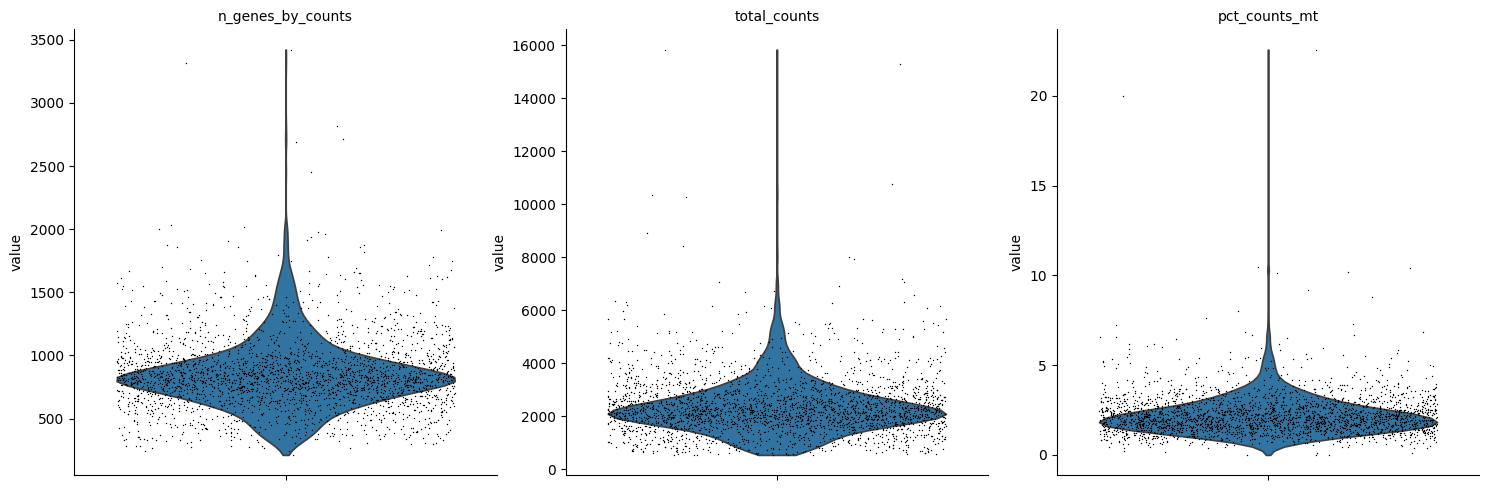

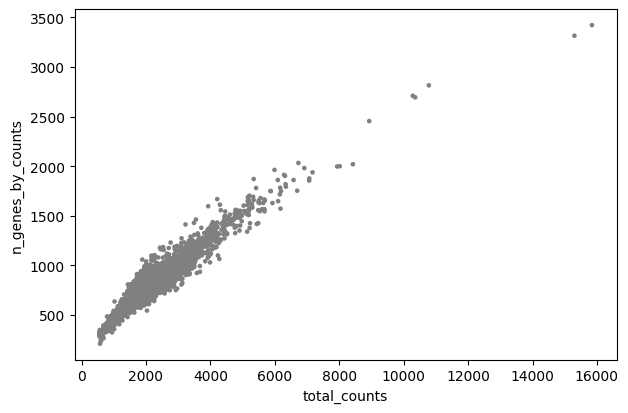

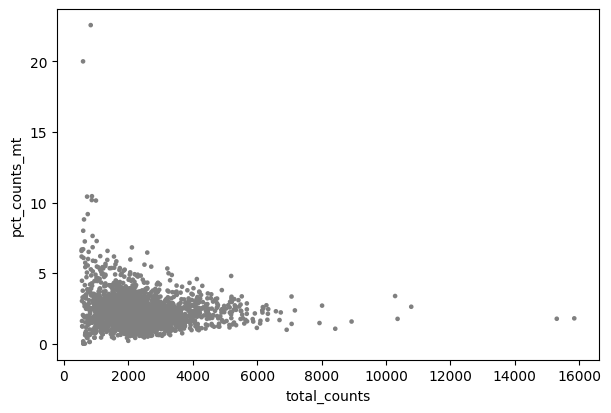

In [6]:
import scanpy as sc

# Violin plots of QC metrics
sc.pl.violin(
    adata_raw,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

# Scatter plots
sc.pl.scatter(
    adata_raw,
    x="total_counts",
    y="n_genes_by_counts"
)

sc.pl.scatter(
    adata_raw,
    x="total_counts",
    y="pct_counts_mt"
)

In [7]:
adata_raw.obs[
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"]
    ].describe()

,n_genes_by_counts,total_counts,pct_counts_mt
count,2700.000000,2700.000000,2700.000000
mean,846.994074,2366.900391,2.215132
std,282.104964,1094.262085,1.165438
min,212.000000,548.000000,0.000000
25%,690.000000,1757.750000,1.536238
50%,817.000000,2197.000000,2.029639
75%,953.250000,2763.000000,2.640218
max,3422.000000,15844.000000,22.569027


In [8]:
candidate_filters = {
    "genes_lt_200": adata_raw.obs["n_genes_by_counts"] < 200,
    "genes_lt_300": adata_raw.obs["n_genes_by_counts"] < 300,
    "genes_gt_2500": adata_raw.obs["n_genes_by_counts"] > 2500,
    "genes_gt_3000": adata_raw.obs["n_genes_by_counts"] > 3000,
    "mt_gt_5": adata_raw.obs["pct_counts_mt"] > 5,
    "mt_gt_10": adata_raw.obs["pct_counts_mt"] > 10,
}

for name, mask in candidate_filters.items():
    n_cells = mask.sum()
    pct_cells = 100 * n_cells / adata_raw.n_obs
    print(f"{name}: {n_cells} cells ({pct_cells:.2f}%)")

genes_lt_200: 0 cells (0.00%)
genes_lt_300: 15 cells (0.56%)
genes_gt_2500: 5 cells (0.19%)
genes_gt_3000: 2 cells (0.07%)
mt_gt_5: 57 cells (2.11%)
mt_gt_10: 6 cells (0.22%)


In [9]:
adata_qc = adata_raw[
    (adata_raw.obs["n_genes_by_counts"] >= 300) &
    (adata_raw.obs["pct_counts_mt"] < 5)
    ].copy()

print(f"Original cells: {adata_raw.n_obs}")
print(f"Remaining cells: {adata_qc.n_obs}")
print(f"Removed cells: {adata_raw.n_obs - adata_qc.n_obs}")
print(f"Percent removed: {(adata_raw.n_obs - adata_qc.n_obs) / adata_raw.n_obs * 100:.2f}%")

Original cells: 2700
Remaining cells: 2633
Removed cells: 67
Percent removed: 2.48%


In [12]:
import numpy as np
from scipy import sparse

gene_detection_counts = np.asarray(
    (adata_qc.X > 0).sum(axis=0)
).ravel()

for threshold in [1, 3, 5, 10]:
    removed = (gene_detection_counts < threshold).sum()
    print(
        f"min_cells={threshold}: "
        f"{removed} genes removed "
        f"({100 * removed / adata_qc.n_vars:.2f}%)"
    )

min_cells=1: 16132 genes removed (49.28%)
min_cells=3: 19046 genes removed (58.18%)
min_cells=5: 20192 genes removed (61.68%)
min_cells=10: 21620 genes removed (66.04%)


In [13]:
n_genes_before = adata_qc.n_vars

sc.pp.filter_genes(adata_qc, min_cells=3)

n_genes_after = adata_qc.n_vars

print(f"Genes before filtering: {n_genes_before}")
print(f"Genes after filtering: {n_genes_after}")
print(f"Genes removed: {n_genes_before - n_genes_after}")
print(
    f"Percent removed: "
    f"{100 * (n_genes_before - n_genes_after) / n_genes_before:.2f}%"
)

Genes before filtering: 32738
Genes after filtering: 13692
Genes removed: 19046
Percent removed: 58.18%
